# Training set optimization

## Plan
1. Background / idea
2. Related work
3. TracIn
4. Data Shapley
5. PEVmean
6. Top-k
7. PCA
8. BPCRR update
9. Findings so far
10. Next steps / ideas


## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fitz

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)

# Resolve project root robustly whether notebook cwd is repo root or notebooks/
cwd = Path.cwd().resolve()
root_candidates = [cwd, cwd.parent, cwd.parent.parent]
PROJECT_ROOT = next((p for p in root_candidates if (p / "src").exists()), cwd)
OUTPUTS = PROJECT_ROOT / "outputs"

# Ensure imports like `from src...` work in notebook cells
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", cwd)
print("project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())
print("outputs exists:", OUTPUTS.exists())

cwd: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\notebooks
project root: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
src exists: True
outputs exists: True


In [2]:
def load_if_exists(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        print(f"Missing: {path}")
        return None
    df = pd.read_csv(path)
    print(f"Loaded {path} -> {df.shape[0]} rows x {df.shape[1]} cols")
    return df


def summarize_perf(df: pd.DataFrame, metric: str = "corr_eval") -> pd.DataFrame:
    cols = [c for c in ["method", "selection_method", "target_island", "n_individuals", metric] if c in df.columns]
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not in dataframe")
    out = (
        df[cols]
        .groupby([c for c in cols if c != metric], dropna=False)[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )
    return out


def display_pdf(
    pdf_files: list[Path],
    page_nums: list[int] | None = None,
    zoom: float = 2.8,
    max_papers: int = 6,
    col_width: float = 7.0,
) -> None:
    import fitz  # PyMuPDF

    show_files = pdf_files[:max_papers]
    if len(show_files) == 0:
        print("No pdf files provided")
        return

    if page_nums is None:
        page_nums = [0] * len(show_files)
    elif len(page_nums) < len(show_files):
        page_nums = page_nums + [0] * (len(show_files) - len(page_nums))

    cols = min(len(show_files), 3)
    rows = int(np.ceil(len(show_files) / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(col_width * cols, col_width * 1.35 * rows),
        dpi=250,
    )
    axes = np.array(axes).reshape(-1)

    for ax, pdf_path, page_num in zip(axes, show_files, page_nums):
        try:
            with fitz.open(pdf_path) as doc:
                page_idx = int(np.clip(page_num, 0, max(len(doc) - 1, 0)))
                page = doc.load_page(page_idx)
                pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), alpha=False)

            img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
            if img.shape[2] > 3:
                img = img[:, :, :3]

            ax.imshow(img, interpolation="nearest")
            ax.set_title(f"{pdf_path.stem}\npage {page_idx + 1}", fontsize=10)
            ax.axis("off")
        except Exception as exc:
            ax.text(0.5, 0.5, f"Failed to render\n{pdf_path.name}\n{exc}", ha="center", va="center")
            ax.axis("off")

    for ax in axes[len(show_files):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 1) Background / idea

- Ultimate goal: Improve genomic prediction
- Kenneths paper: Worse across population

**IDEA**

For certain islands, maybe some training individuals do more harm than good. Can we improve prediction on target islands by "optimizing" the training set?

## 2) Related work

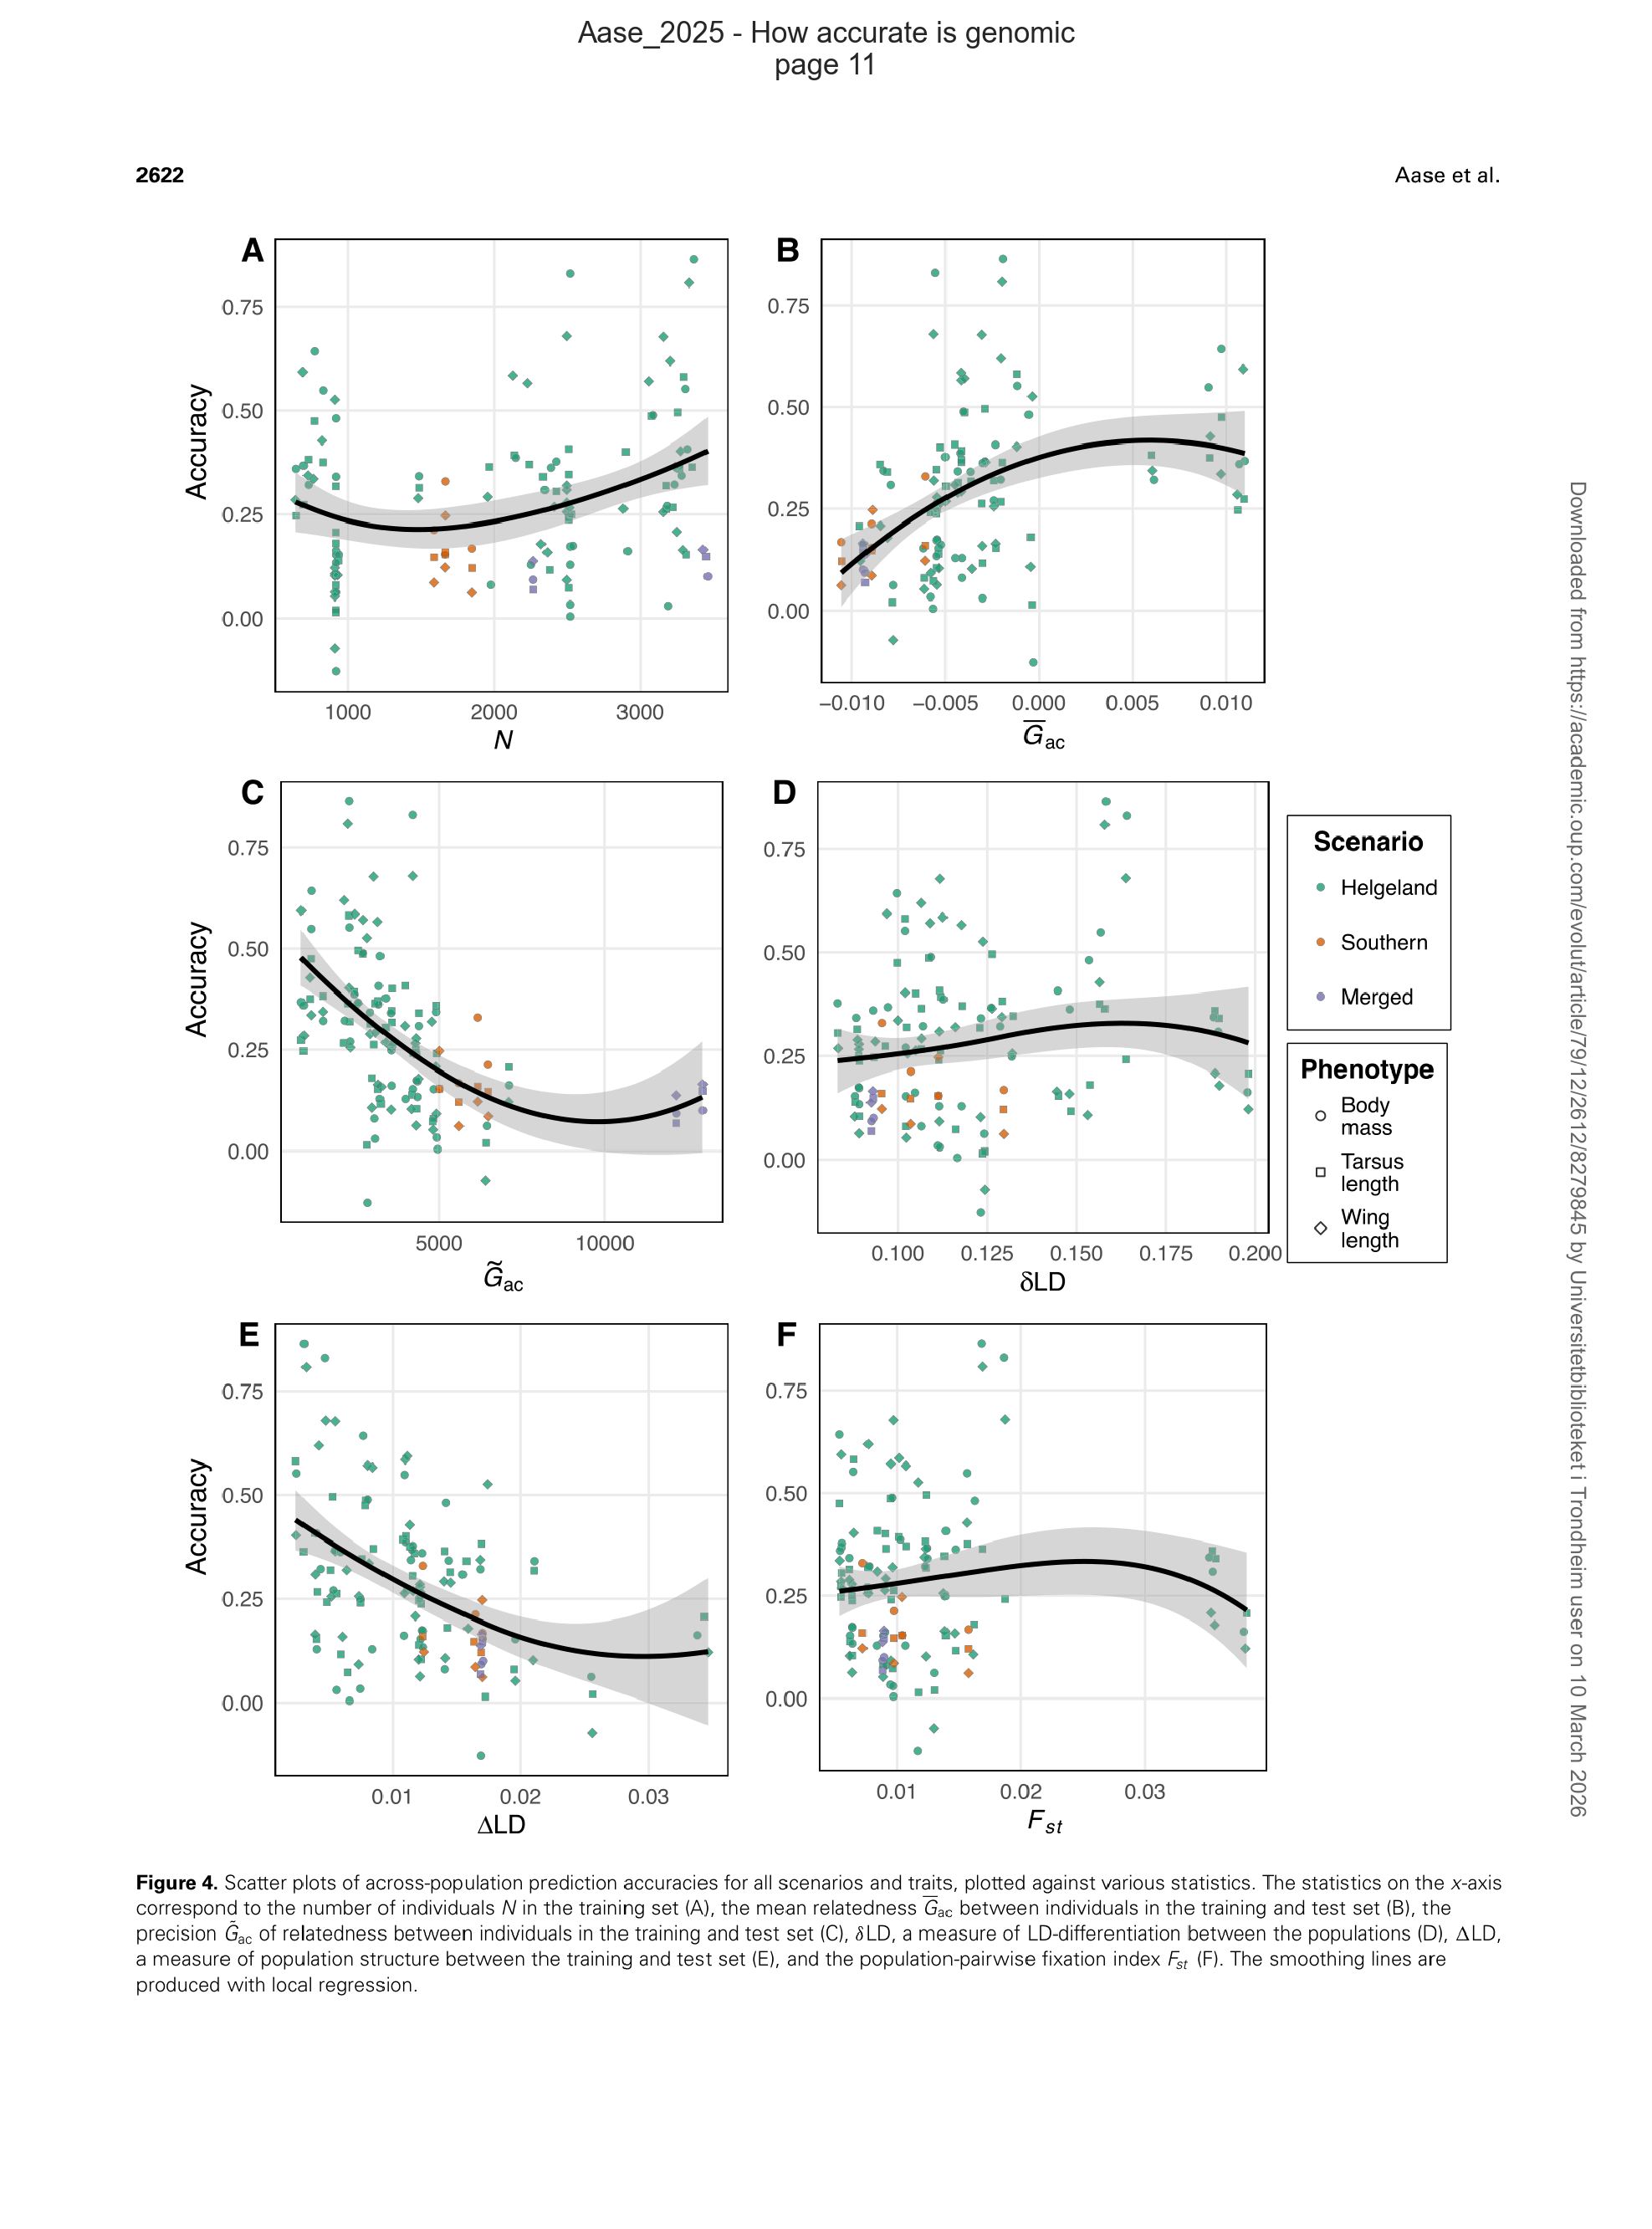

In [3]:
display_pdf(
    [PROJECT_ROOT / "papers" / "Aase_2025 - How accurate is genomic.pdf"],
    [10],
    zoom=3.2,
    col_width=8.0,
)

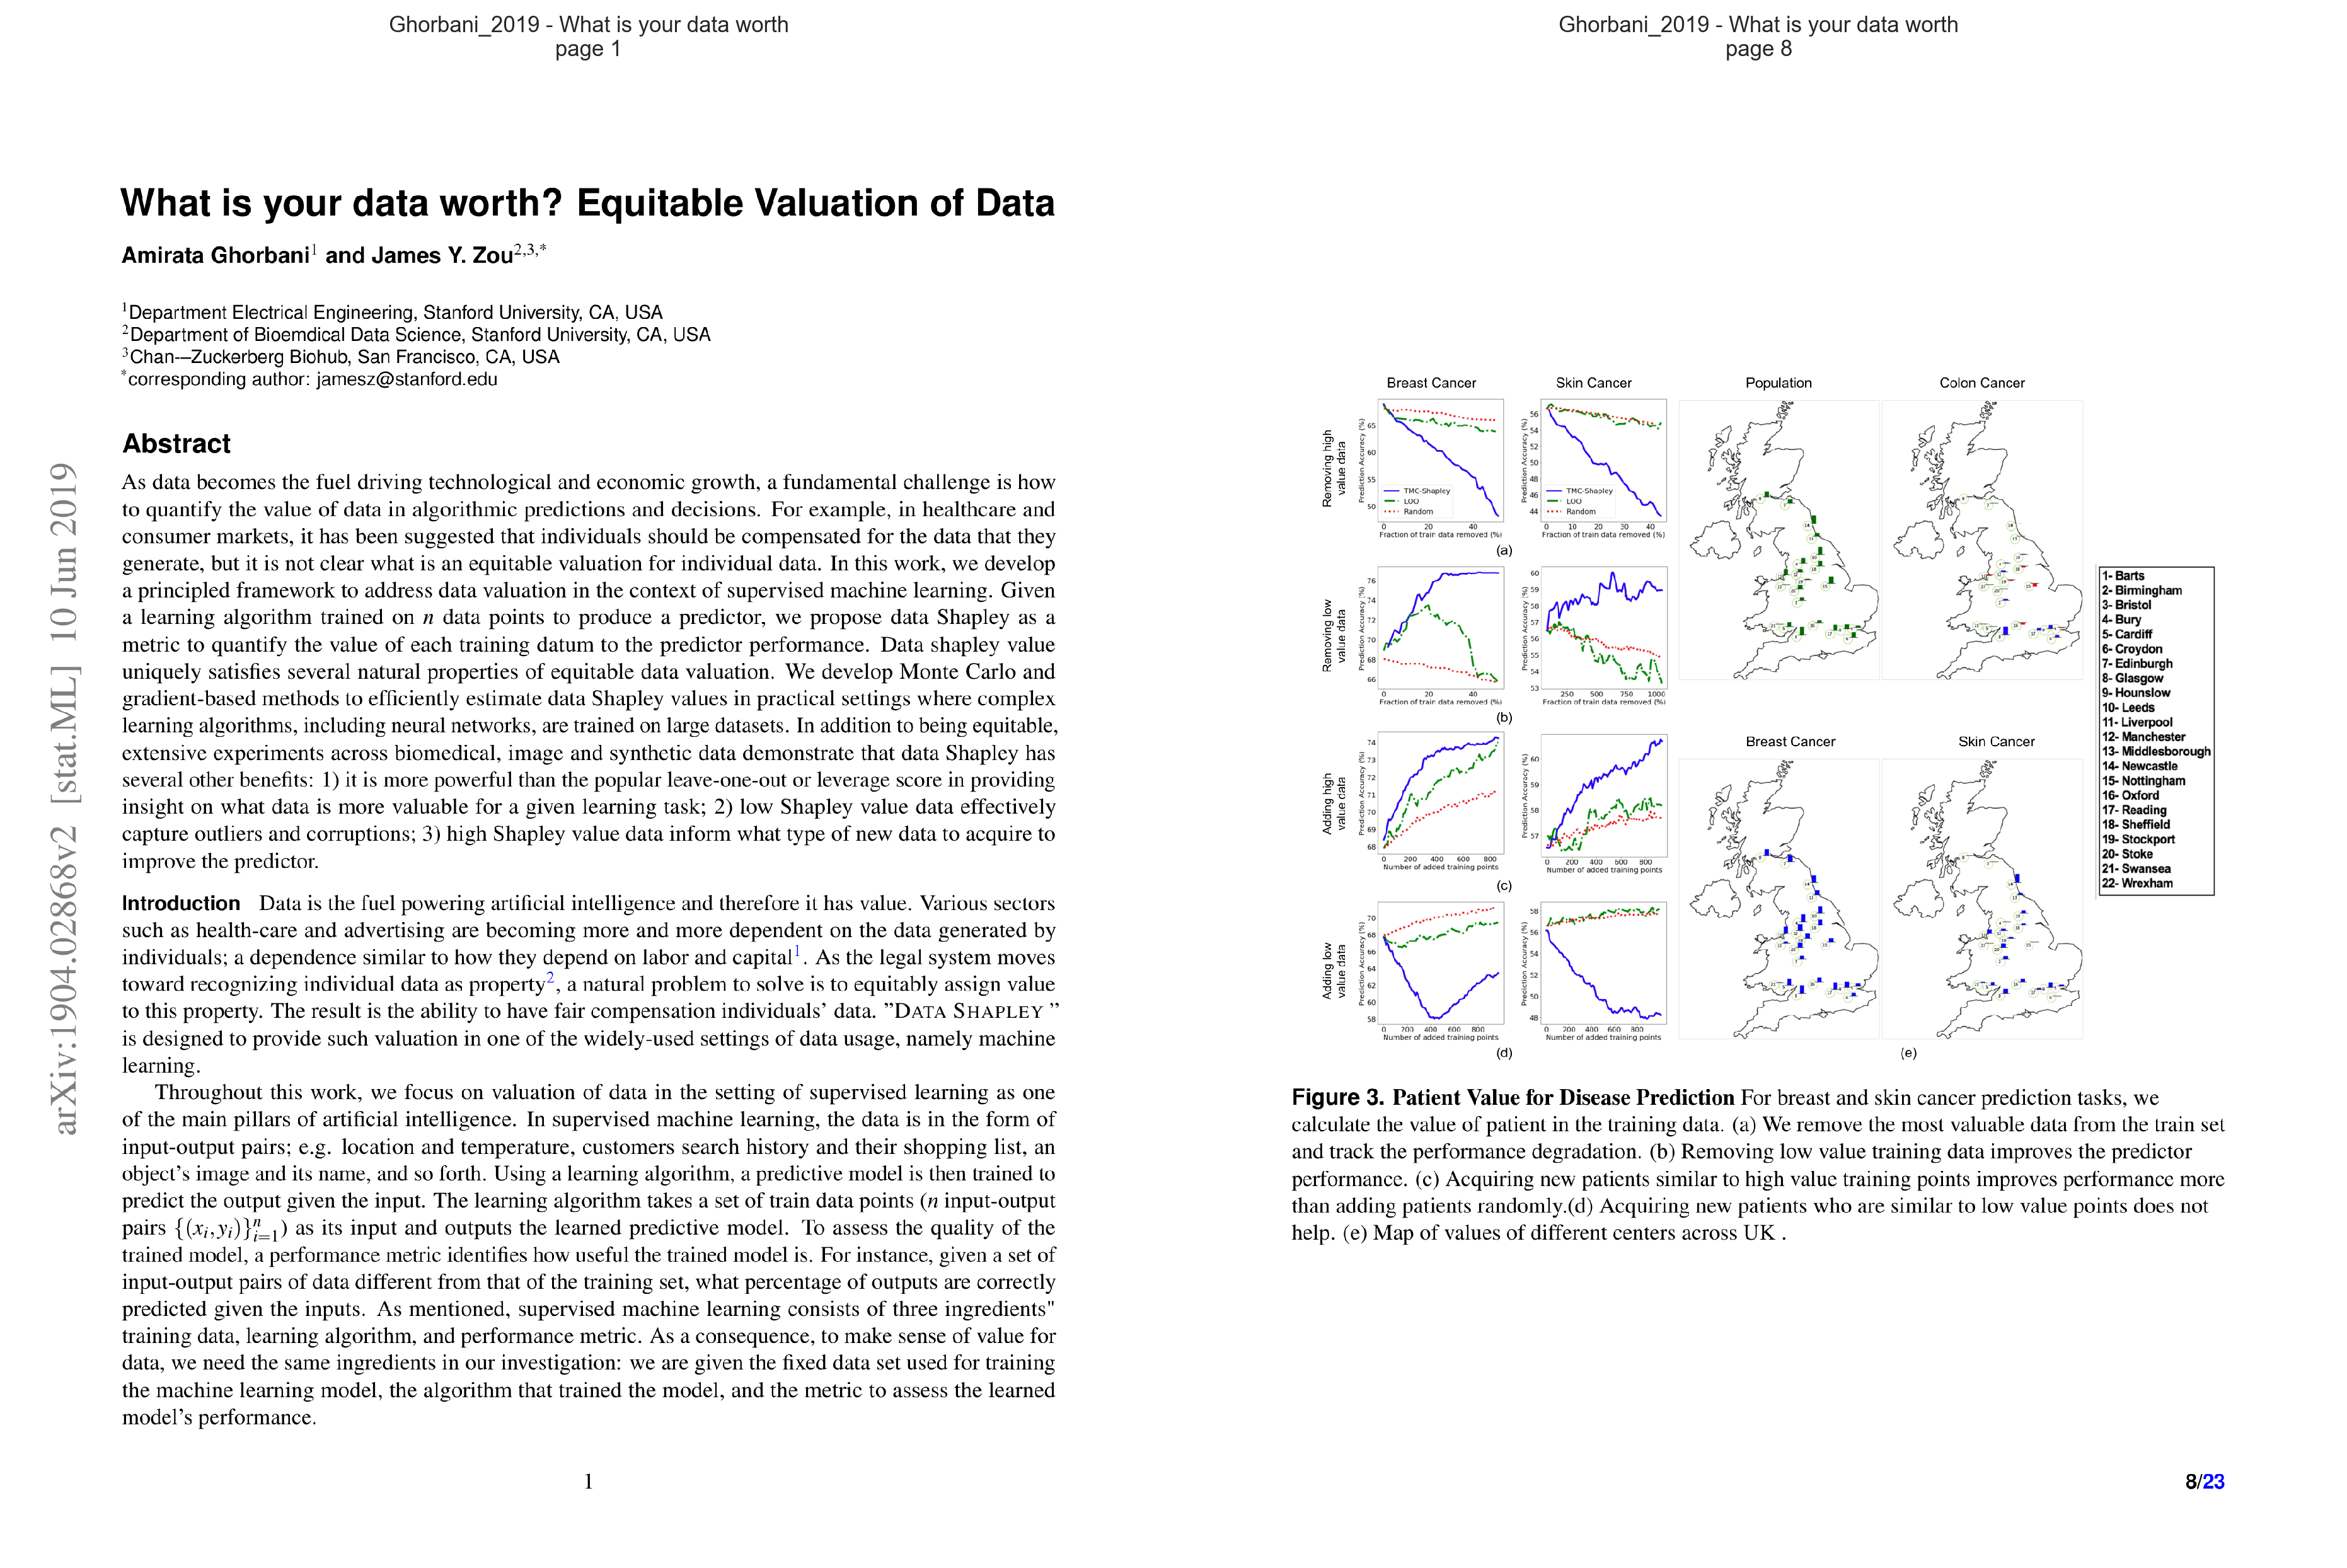

In [4]:
display_pdf(
    [
        PROJECT_ROOT / "papers" / "Ghorbani_2019 - What is your data worth.pdf",
        PROJECT_ROOT / "papers" / "Ghorbani_2019 - What is your data worth.pdf",
    ],
    [0, 7],
    zoom=3.2,
    col_width=7.5,
)

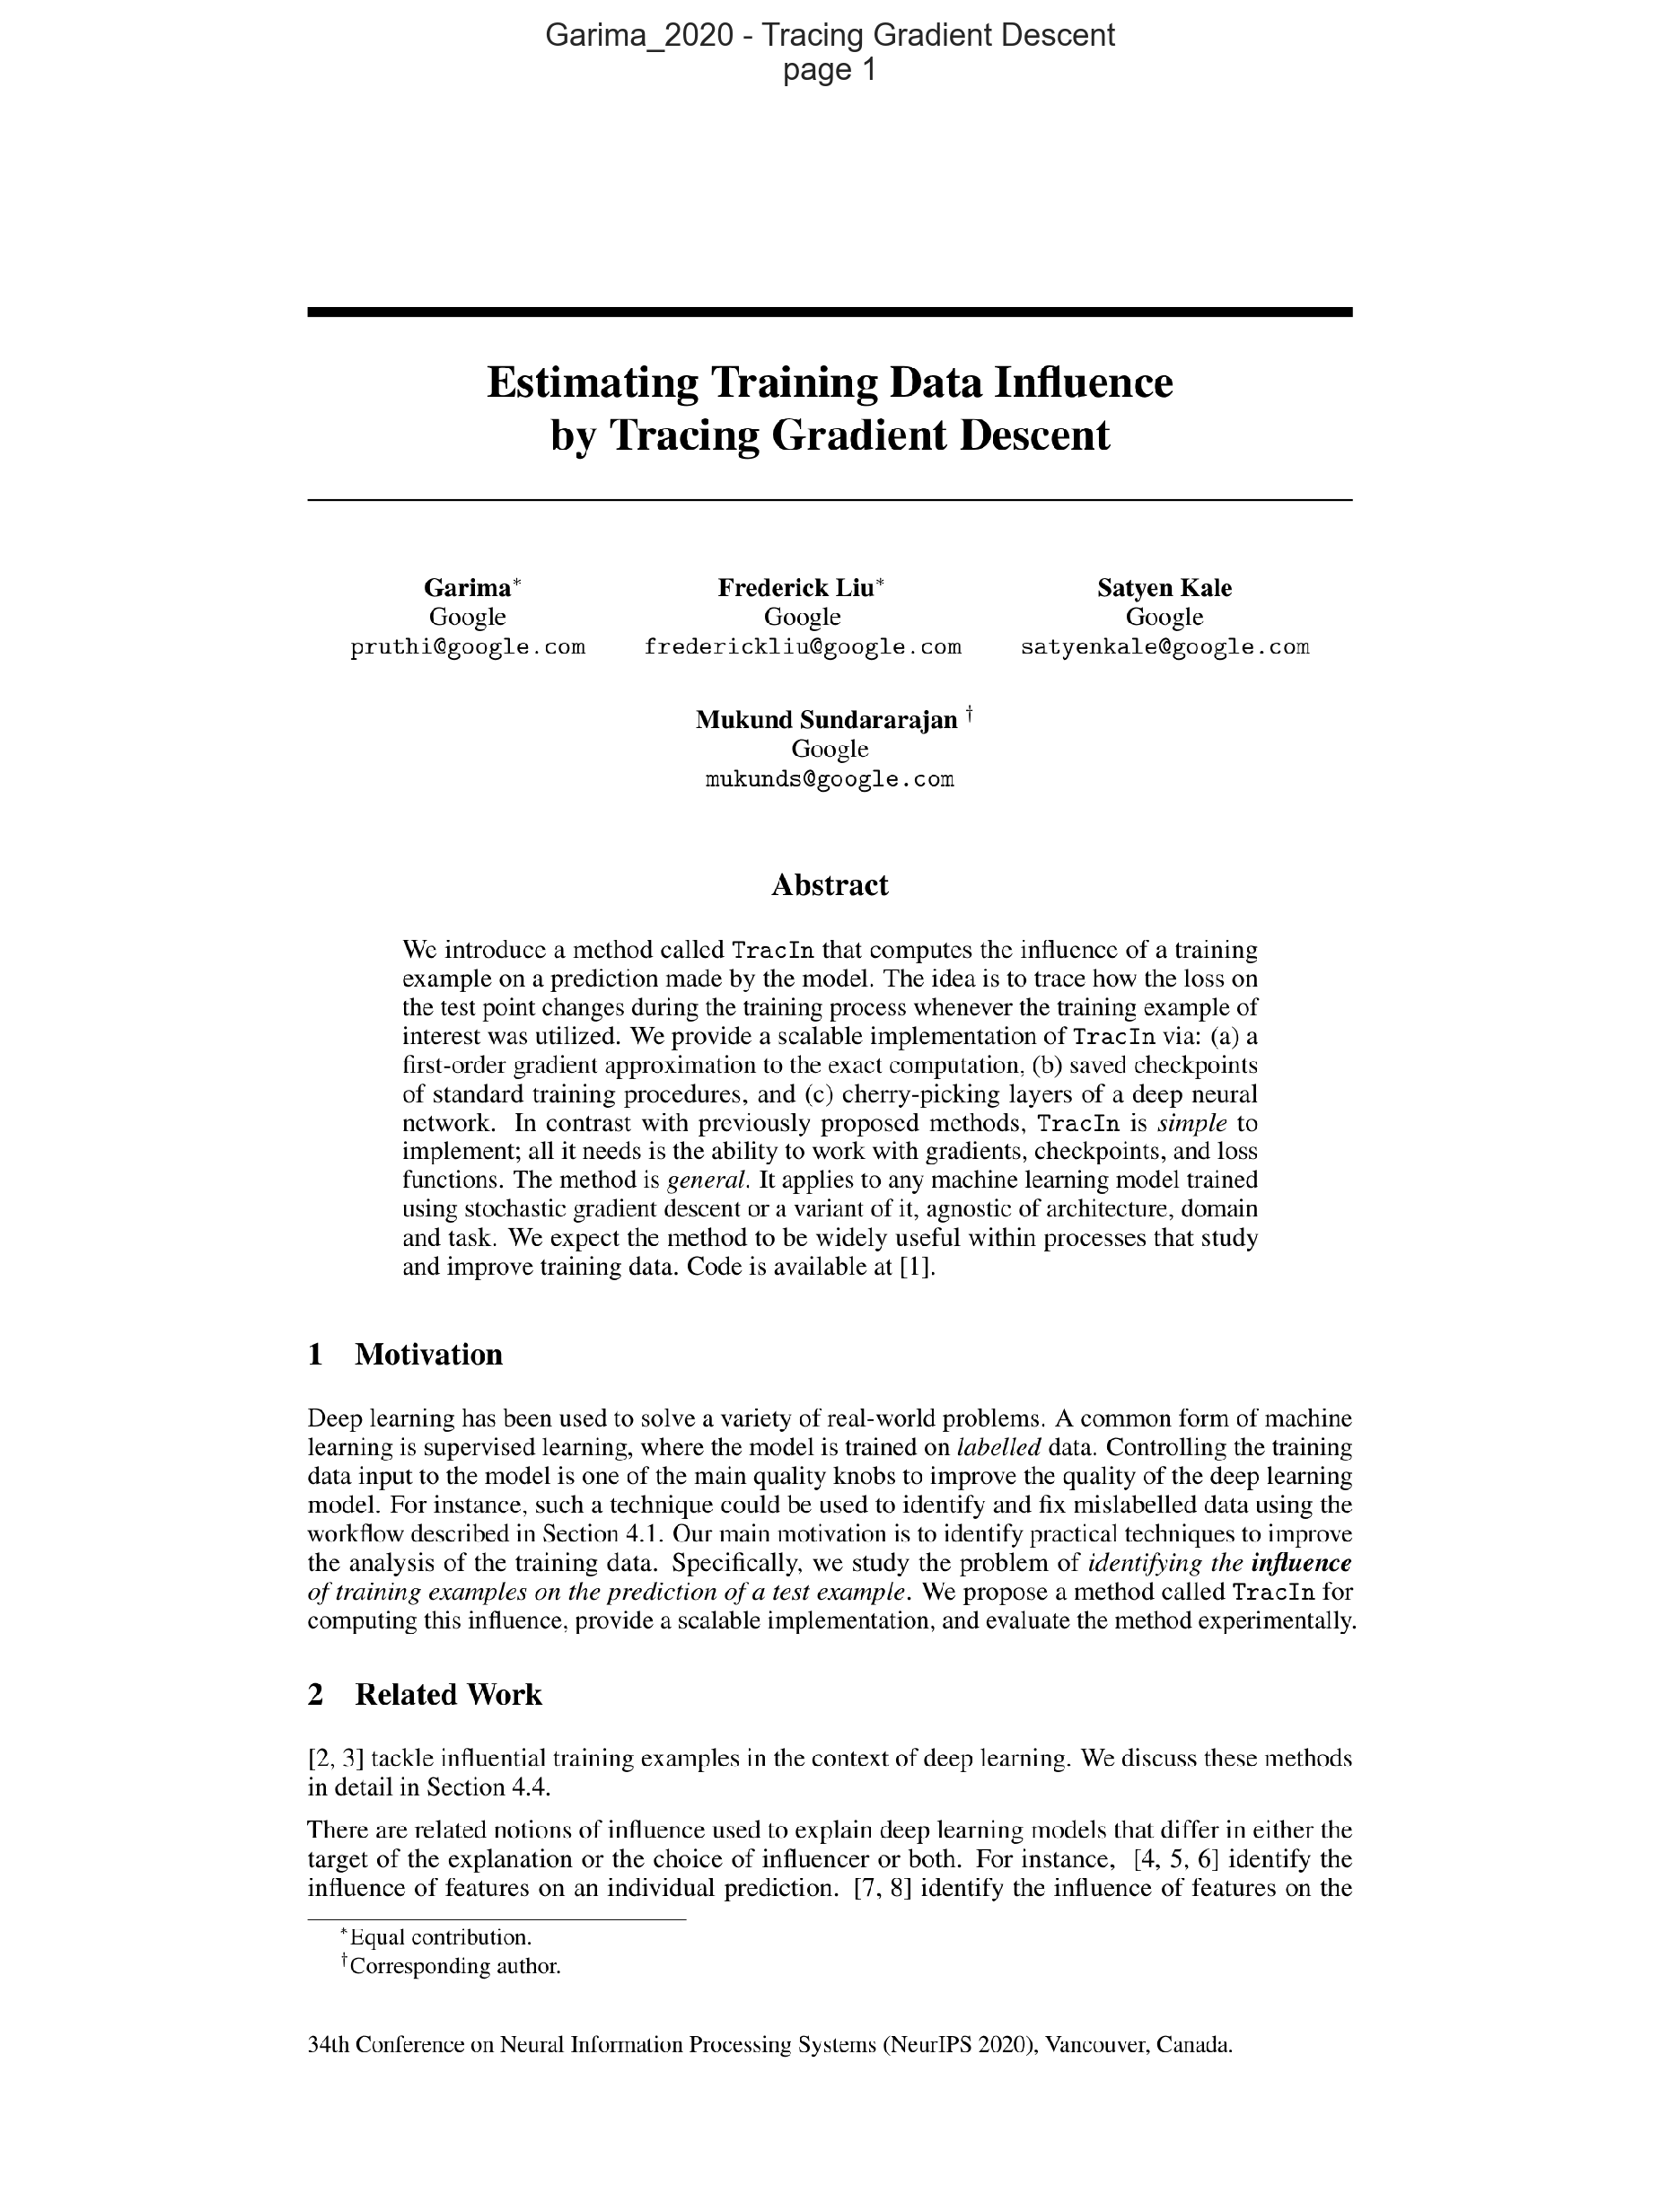

In [5]:
display_pdf([PROJECT_ROOT / "papers" / "Garima_2020 - Tracing Gradient Descent.pdf"], [0], zoom=3.2, col_width=7.5)

In [6]:
# Small comparison table for discussion
method_table = pd.DataFrame(
    [
        {"method": "TracIn", "signal": "influence/gradient", "cost": "high", "status": "prototype"},
        {"method": "Data Shapley", "signal": "marginal contribution", "cost": "very high", "status": "prototype"},
        {"method": "PEVmean", "signal": "prediction error variance", "cost": "medium-high", "status": "tested"},
        {"method": "Top-k avgGRM", "signal": "relatedness", "cost": "low-medium", "status": "tested"},
        {"method": "Top-k PC distance", "signal": "representation proximity", "cost": "low-medium", "status": "tested"},
        {"method": "BPCRR (INLA)", "signal": "Bayesian PCRR model fit", "cost": "high", "status": "running"},
    ]
)
display(method_table)

,method,signal,cost,status
0,TracIn,influence/gradient,high,prototype
1,Data Shapley,marginal contribution,very high,prototype
2,PEVmean,prediction error variance,medium-high,tested
3,Top-k avgGRM,relatedness,low-medium,tested
4,Top-k PC distance,representation proximity,low-medium,tested
5,BPCRR (INLA),Bayesian PCRR model fit,high,running


Notes after running:
- Adjust status/cost labels if needed.
- Keep this table simple so it is easy to discuss quickly.

## 3) TracIn

- Summarize what was implemented and what was too expensive.
- Goal here: quickly show available outputs (if present).

In [7]:
TRACIN_CANDIDATES = sorted(OUTPUTS.glob("**/*tracin*results*.csv")) + sorted(OUTPUTS.glob("**/*tracin*summary*.csv"))

if len(TRACIN_CANDIDATES) == 0:
    print("No TracIn result files found under outputs/.")
else:
    print("Found TracIn-related files:")
    for p in TRACIN_CANDIDATES[:10]:
        print(" -", p)
    tracin_df = load_if_exists(TRACIN_CANDIDATES[0])
    if tracin_df is not None:
        display(tracin_df.head(5))

No TracIn result files found under outputs/.


Notes after running:
- If no file is found, mention TracIn is exploratory/prototype.
- If file exists, note one key pattern and one limitation.

## 4) Data Shapley

- Briefly state which variant you used (e.g., TMC-Shapley).
- Mention whether the current focus is quality or runtime feasibility.

In [8]:
SHAPLEY_CANDIDATES = sorted(OUTPUTS.glob("**/*shapley*results*.csv")) + sorted(OUTPUTS.glob("**/*shapley*summary*.csv"))

if len(SHAPLEY_CANDIDATES) == 0:
    print("No Data Shapley result files found under outputs/.")
else:
    print("Found Data Shapley files:")
    for p in SHAPLEY_CANDIDATES[:10]:
        print(" -", p)
    shap_df = load_if_exists(SHAPLEY_CANDIDATES[0])
    if shap_df is not None:
        display(shap_df.head(5))

No Data Shapley result files found under outputs/.


Notes after running:
- Mention one concrete runtime/variance observation.
- Keep this section short unless you have robust final numbers.

## 5) PEVmean

- Remind group of objective and optimizer setup.
- Focus on whether selected subsets improve downstream prediction.

Found PEVmean files:
 - C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pevmean_ga\pevmean_ga_results.csv
 - C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pevmean_ga\shards\shard_000\body_mass\pevmean_ga_results.csv
 - C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pevmean_ga\shards\shard_001\body_mass\pevmean_ga_results.csv
 - C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pevmean_ga\shards\shard_002\body_mass\pevmean_ga_results.csv
 - C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pevmean_ga\shards\shard_003\body_mass\pevmean_ga_results.csv
 - C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pevmean_ga\shards\shard_004\body_mass\pevmean_ga_results.csv
 - C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pevmean_ga\shards\shard_005\body_mass\pevmean_ga_results.csv
 - C:\Users\Simen\OneDrive - NTNU\FYSMAT

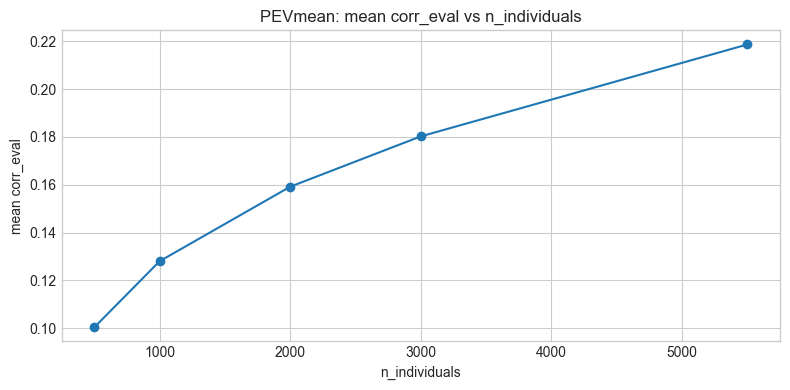

In [9]:
PEV_CANDIDATES = sorted(OUTPUTS.glob("**/*pevmean*results*.csv")) + sorted(OUTPUTS.glob("**/*pevmean*summary*.csv"))

if len(PEV_CANDIDATES) == 0:
    print("No PEVmean files found under outputs/.")
else:
    print("Found PEVmean files:")
    for p in PEV_CANDIDATES[:10]:
        print(" -", p)
    pev_df = load_if_exists(PEV_CANDIDATES[0])
    if pev_df is not None and {"n_individuals", "corr_eval"}.issubset(pev_df.columns):
        tmp = pev_df.groupby("n_individuals", dropna=False)["corr_eval"].mean().reset_index()
        plt.figure(figsize=(8, 4))
        plt.plot(tmp["n_individuals"], tmp["corr_eval"], marker="o")
        plt.title("PEVmean: mean corr_eval vs n_individuals")
        plt.xlabel("n_individuals")
        plt.ylabel("mean corr_eval")
        plt.tight_layout()
        plt.show()

Notes after running:
- Note whether PEVmean gives a gain over random at practical k.
- Mention runtime vs quality compared to simpler rank-based methods.

## 6) Top-k

- This is the main results section for now (ridge).
- Compare random vs ranked approaches over k.

Loaded C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pca_source_rank_weight_test4\pca_source_rank_weight_results.csv -> 1712 rows x 20 cols
Using ridge results from: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pca_source_rank_weight_test4\pca_source_rank_weight_results.csv


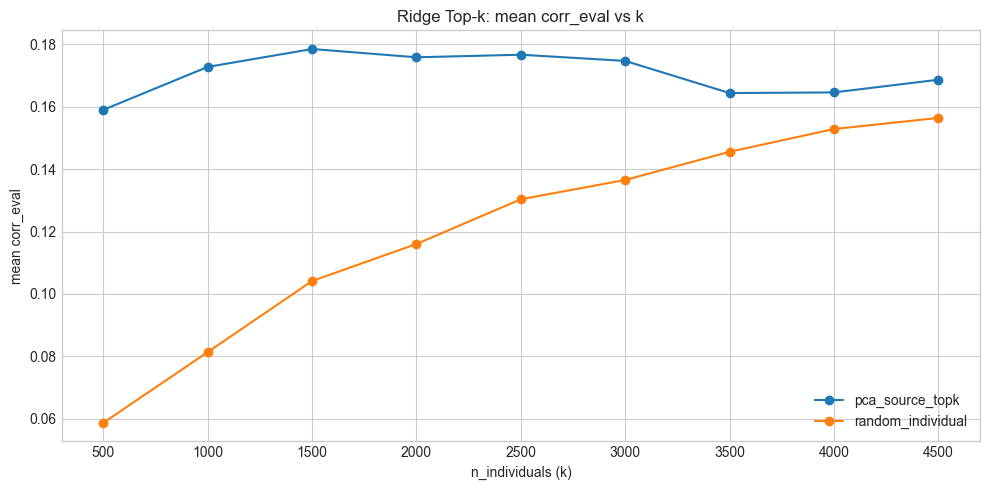

In [10]:
RIDGE_RESULTS_CANDIDATES = [
    OUTPUTS / "pca_source_rank_weight_test4" / "pca_source_rank_weight_results.csv",
    OUTPUTS / "pca_source_rank_weight_test3" / "pca_source_rank_weight_results.csv",
    OUTPUTS / "pca_source_rank_weight_test2" / "pca_source_rank_weight_results.csv",
    OUTPUTS / "pca_source_rank_weight_test1" / "pca_source_rank_weight_results.csv",
    OUTPUTS / "avggrm_rank_weight_all" / "body_mass" / "avggrm_rank_weight_results.csv",
]

ridge_df = None
for p in RIDGE_RESULTS_CANDIDATES:
    ridge_df = load_if_exists(p)
    if ridge_df is not None:
        print("Using ridge results from:", p)
        break

if ridge_df is not None and {"method", "n_individuals", "corr_eval"}.issubset(ridge_df.columns):
    keep = ridge_df.copy()
    if "analysis" in keep.columns:
        keep = keep[keep["analysis"] == "ranked_subset"]

    perf = keep.groupby(["method", "n_individuals"], dropna=False)["corr_eval"].mean().reset_index()
    plt.figure(figsize=(10, 5))
    for method, sub in perf.groupby("method"):
        sub = sub.sort_values("n_individuals")
        plt.plot(sub["n_individuals"], sub["corr_eval"], marker="o", label=str(method))
    plt.title("Ridge Top-k: mean corr_eval vs k")
    plt.xlabel("n_individuals (k)")
    plt.ylabel("mean corr_eval")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

Notes after running:
- Point out where ranked methods beat random and where gains flatten with larger k.
- Mention if trends differ by target island.

## 7) PCA

- Show effect of n_components if available.
- If missing this dimension in file, use method-level comparison only.

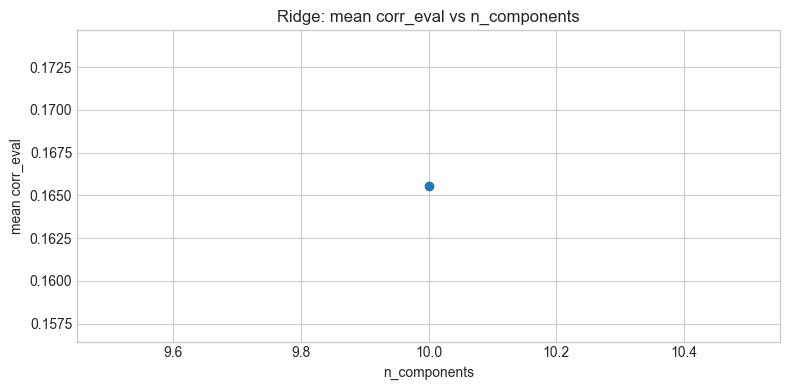

In [11]:
if ridge_df is not None:
    if {"n_components", "corr_eval"}.issubset(ridge_df.columns):
        pca_perf = ridge_df.groupby("n_components", dropna=False)["corr_eval"].mean().reset_index()
        pca_perf = pca_perf.sort_values("n_components")
        plt.figure(figsize=(8, 4))
        plt.plot(pca_perf["n_components"], pca_perf["corr_eval"], marker="o")
        plt.title("Ridge: mean corr_eval vs n_components")
        plt.xlabel("n_components")
        plt.ylabel("mean corr_eval")
        plt.tight_layout()
        plt.show()
    elif {"method", "corr_eval"}.issubset(ridge_df.columns):
        method_perf = ridge_df.groupby("method", dropna=False)["corr_eval"].mean().sort_values(ascending=False)
        display(method_perf.to_frame("mean_corr_eval"))
    else:
        print("No PCA-relevant columns found in ridge results yet.")
else:
    print("ridge_df not loaded yet. Run the Top-k section code cell first.")

Notes after running:
- Mention chosen default n_components and why.
- Note any stability or runtime trade-off.

## 8) BPCRR update

- BPCRR script and logging are in place.
- This section tracks what has finished and shows preliminary curves if available.

Loaded C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\bpcrr_inla\bpcrr_inla_rank_select_results.csv -> 127 rows x 17 cols


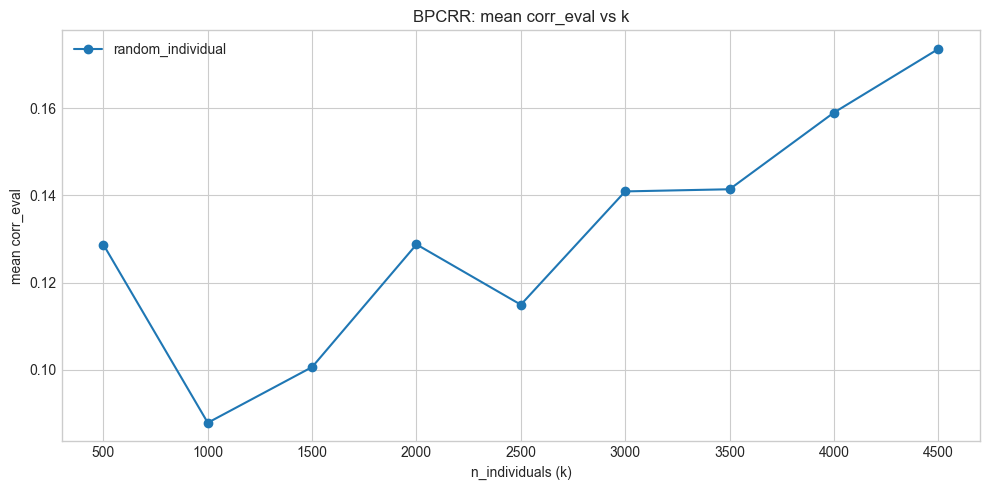

In [12]:
bpcrr_path = OUTPUTS / "bpcrr_inla" / "bpcrr_inla_rank_select_results.csv"
bpcrr_df = load_if_exists(bpcrr_path)

if bpcrr_df is not None and {"method", "n_individuals", "corr_eval"}.issubset(bpcrr_df.columns):
    keep = bpcrr_df.copy()
    if "analysis" in keep.columns:
        keep = keep[keep["analysis"] == "ranked_subset"]

    perf = keep.groupby(["method", "n_individuals"], dropna=False)["corr_eval"].mean().reset_index()
    plt.figure(figsize=(10, 5))
    for method, sub in perf.groupby("method"):
        sub = sub.sort_values("n_individuals")
        plt.plot(sub["n_individuals"], sub["corr_eval"], marker="o", label=str(method))
    plt.title("BPCRR: mean corr_eval vs k")
    plt.xlabel("n_individuals (k)")
    plt.ylabel("mean corr_eval")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("BPCRR file missing or not enough columns yet.")

Notes after running:
- If still incomplete, report progress status and expected completion window.
- If complete, compare BPCRR trend against ridge at matched k.

## 9) Findings so far

- Keep this concise: 3-5 concrete points.
- Use table below to avoid hand-picking numbers.

In [13]:
summary_rows = []

if ridge_df is not None and {"method", "corr_eval"}.issubset(ridge_df.columns):
    r = ridge_df.groupby("method", dropna=False)["corr_eval"].mean().sort_values(ascending=False).head(5).reset_index()
    r.insert(0, "model", "ridge")
    summary_rows.append(r.rename(columns={"corr_eval": "mean_corr_eval"}))

if bpcrr_df is not None and {"method", "corr_eval"}.issubset(bpcrr_df.columns):
    b = bpcrr_df.groupby("method", dropna=False)["corr_eval"].mean().sort_values(ascending=False).head(5).reset_index()
    b.insert(0, "model", "bpcrr")
    summary_rows.append(b.rename(columns={"corr_eval": "mean_corr_eval"}))

if summary_rows:
    findings_df = pd.concat(summary_rows, ignore_index=True)
    display(findings_df)
else:
    print("No findings table yet. Run Top-k and BPCRR cells first.")

,model,method,mean_corr_eval
0,ridge,pca_source_weight_exponential,0.174735
1,ridge,pca_source_apriori_topk,0.172714
2,ridge,pca_source_topk,0.170616
3,ridge,full_source_unweighted,0.167013
4,ridge,pca_source_alpha,0.153155
5,bpcrr,full_source_unweighted,0.182485
6,bpcrr,random_individual,0.129623


Notes after running:
- Convert table into 3-5 bullet conclusions.
- Mention at least one caveat (runtime, variance, or incomplete BPCRR grid).

## 10) Ideas / next steps

- Fill this live during discussion.
- Keep it operational: priorities, owners, and expected completion windows.

In [14]:
next_steps = pd.DataFrame(
    [
        {"priority": 1, "task": "Finish BPCRR reduced grid", "owner": "", "eta": "", "status": "in progress"},
        {"priority": 2, "task": "Compare BPCRR vs ridge at matched k", "owner": "", "eta": "", "status": "todo"},
        {"priority": 3, "task": "Finalize method recommendation", "owner": "", "eta": "", "status": "todo"},
    ]
)
display(next_steps)

,priority,task,owner,eta,status
0,1,Finish BPCRR reduced grid,,,in progress
1,2,Compare BPCRR vs ridge at matched k,,,todo
2,3,Finalize method recommendation,,,todo


Notes after running:
- Agree on 2-3 concrete decisions before ending the meeting.
- Update owner/eta/status in the table above.